# Analisi statistica migliorata per la previsione degli incendi

Questo notebook prepara e analizza il dataset `dataset_pulito3_lag_target_final.csv` con particolare attenzione a:

- conservazione delle osservazioni utili;
- corretto ordinamento temporale per cella geografica;
- prevenzione del data leakage;
- statistiche descrittive robuste;
- correlazioni adatte a target binari e di conteggio;
- intervalli di confidenza bootstrap;
- confronto tra celle con e senza incendio futuro;
- valutazione dello sbilanciamento dei target;
- selezione preliminare delle feature.

> Le feature temporali sono calcolate esclusivamente usando osservazioni precedenti alla riga corrente.

## 1. Configurazione, import e caricamento dati

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

INPUT_FILE = Path("dataset_pulito3_lag_target_final.csv")
OUTPUT_FILE = Path("dataset_pulito5_migliorato.csv")
RANDOM_STATE = 42
N_BOOTSTRAP = 10_000

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"File non trovato: {INPUT_FILE.resolve()}\n"
        "Inserire il CSV nella stessa cartella del notebook oppure modificare INPUT_FILE."
    )

df_raw = pd.read_csv(INPUT_FILE)

# Conversione robusta della data.
if "date" not in df_raw.columns:
    raise KeyError("La colonna obbligatoria 'date' non è presente nel dataset.")

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")

required_columns = {
    "date", "lat_cell", "lon_cell", "daily_frp_mean",
    "fire_next_1d", "fire_next_3d", "fire_next_7d",
    "fire_count_next_7d"
}
missing_required = sorted(required_columns - set(df_raw.columns))
if missing_required:
    raise KeyError(f"Colonne obbligatorie mancanti: {missing_required}")

print(f"Righe iniziali: {len(df_raw):,}")
print(f"Colonne iniziali: {df_raw.shape[1]:,}")
print(f"Intervallo temporale: {df_raw['date'].min()} -> {df_raw['date'].max()}")
print(f"Celle geografiche: {df_raw[['lat_cell', 'lon_cell']].drop_duplicates().shape[0]:,}")
display(df_raw.head())

Righe iniziali: 1,547,140
Colonne iniziali: 20
Intervallo temporale: 2026-06-18 00:00:00 -> 2026-07-15 00:00:00
Celle geografiche: 55,255


,date,lat_cell,lon_cell,fire_count,daily_frp_mean,source_rows,month,day_of_year,week,sin_doy,cos_doy,fire_count_last_1d,fire_count_last_3d,fire_count_last_7d,frp_mean_last_7d,days_since_last_fire,fire_next_1d,fire_next_3d,fire_next_7d,fire_count_next_7d
0,2026-06-18,-48.8000,-70.3000,0,NaN,0,6,169,25,0.2303,-0.9731,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
1,2026-06-19,-48.8000,-70.3000,0,NaN,0,6,170,25,0.2135,-0.9769,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
2,2026-06-20,-48.8000,-70.3000,0,NaN,0,6,171,25,0.1967,-0.9805,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,1.0000,1.0000
3,2026-06-21,-48.8000,-70.3000,0,NaN,0,6,172,25,0.1798,-0.9837,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,1.0000,1.0000
4,2026-06-22,-48.8000,-70.3000,0,NaN,0,6,173,26,0.1628,-0.9867,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0000,1.0000,1.0000


## 2. Controlli di qualità e duplicati

In [2]:
quality_report = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_n": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean().mul(100),
    "n_unique": df_raw.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

duplicate_key = ["lat_cell", "lon_cell", "date"]
duplicate_rows = df_raw.duplicated(subset=duplicate_key, keep=False)

print(f"Date non valide: {df_raw['date'].isna().sum():,}")
print(f"Righe duplicate sulla chiave {duplicate_key}: {duplicate_rows.sum():,}")
display(quality_report)

if duplicate_rows.any():
    display(
        df_raw.loc[duplicate_rows]
        .sort_values(duplicate_key)
        .head(20)
    )

Date non valide: 0
Righe duplicate sulla chiave ['lat_cell', 'lon_cell', 'date']: 0


,dtype,missing_n,missing_pct,n_unique
daily_frp_mean,float64,1425640,92.1468,35491
frp_mean_last_7d,float64,1057940,68.3804,60319
days_since_last_fire,float64,610210,39.4412,27
fire_count_last_7d,float64,386785,25.0000,150
fire_count_next_7d,float64,386785,25.0000,148
fire_next_7d,float64,386785,25.0000,2
fire_count_last_3d,float64,165765,10.7143,94
fire_next_3d,float64,165765,10.7143,2
fire_count_last_1d,float64,55255,3.5714,94
fire_next_1d,float64,55255,3.5714,2


## 3. Pulizia conservativa dei dati

I conteggi storici mancanti all'inizio della serie vengono impostati a zero **solo quando il significato è coerente con “nessun evento storico disponibile”**. Le variabili continue non vengono riempite con medie globali, perché ciò potrebbe alterare la distribuzione.

Per `days_since_last_fire`, i valori mancanti sono sostituiti con un valore superiore al massimo osservato, accompagnato da una variabile indicatrice. In questo modo il modello può distinguere una lunga assenza di incendi da un dato originariamente mancante.

In [3]:
df = df_raw.copy()

# Elimina solo righe prive di informazioni strutturali indispensabili.
df = df.dropna(subset=["date", "lat_cell", "lon_cell"]).copy()

# Ordine temporale obbligatorio per prevenire errori nelle feature lag/rolling.
df = df.sort_values(["lat_cell", "lon_cell", "date"]).reset_index(drop=True)

count_lag_columns = [
    c for c in [
        "fire_count_last_1d", "fire_count_last_3d", "fire_count_last_7d"
    ] if c in df.columns
]

for col in count_lag_columns:
    df[f"{col}_was_missing"] = df[col].isna().astype("int8")
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

# FRP giornaliero: zero è coerente con una giornata senza energia radiativa rilevata.
df["daily_frp_mean_was_missing"] = df["daily_frp_mean"].isna().astype("int8")
df["daily_frp_mean"] = pd.to_numeric(df["daily_frp_mean"], errors="coerce").fillna(0).clip(lower=0)

if "days_since_last_fire" in df.columns:
    df["days_since_last_fire"] = pd.to_numeric(df["days_since_last_fire"], errors="coerce")
    df["days_since_last_fire_was_missing"] = df["days_since_last_fire"].isna().astype("int8")
    observed_max = df["days_since_last_fire"].max(skipna=True)
    fallback = 365 if pd.isna(observed_max) else max(365, float(observed_max) + 1)
    df["days_since_last_fire"] = df["days_since_last_fire"].fillna(fallback).clip(lower=0)

# Target: non vengono imputati. Le righe senza target non possono essere usate nel training supervisionato.
target_columns = ["fire_next_1d", "fire_next_3d", "fire_next_7d", "fire_count_next_7d"]
for col in target_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["fire_next_1d", "fire_next_3d", "fire_next_7d"]:
    invalid = df[col].dropna().loc[~df[col].dropna().isin([0, 1])]
    if len(invalid):
        raise ValueError(f"Il target binario '{col}' contiene valori diversi da 0 e 1.")

print(f"Righe dopo la pulizia strutturale: {len(df):,}")
print("Valori mancanti nei target:")
display(df[target_columns].isna().sum().to_frame("missing_n"))

Righe dopo la pulizia strutturale: 1,547,140
Valori mancanti nei target:


,missing_n
fire_next_1d,55255
fire_next_3d,165765
fire_next_7d,386785
fire_count_next_7d,386785


## 4. Feature temporali più informative e senza leakage

In [4]:
group_keys = ["lat_cell", "lon_cell"]
grouped_frp = df.groupby(group_keys, sort=False)["daily_frp_mean"]

# Tutte le finestre iniziano con shift(1): la riga corrente e il futuro non entrano nella feature.
for window in [3, 7, 14, 30]:
    shifted = grouped_frp.shift(1)
    rolling = shifted.groupby([df[k] for k in group_keys]).rolling(
        window=window, min_periods=1
    )

    df[f"frp_mean_last_{window}d_calc"] = rolling.mean().reset_index(level=group_keys, drop=True)
    df[f"frp_std_last_{window}d_calc"] = rolling.std(ddof=1).reset_index(level=group_keys, drop=True).fillna(0)
    df[f"frp_max_last_{window}d_calc"] = rolling.max().reset_index(level=group_keys, drop=True)
    df[f"frp_median_last_{window}d_calc"] = rolling.median().reset_index(level=group_keys, drop=True)

# Trend recente: media degli ultimi 3 giorni meno media degli ultimi 7 giorni.
df["frp_trend_3d_vs_7d"] = (
    df["frp_mean_last_3d_calc"] - df["frp_mean_last_7d_calc"]
)

# Variabilità relativa, resa numericamente stabile.
df["frp_cv_last_7d"] = (
    df["frp_std_last_7d_calc"] /
    df["frp_mean_last_7d_calc"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan).fillna(0)

# Stagionalità ciclica, se non già presente o per uniformarne la definizione.
df["month_calc"] = df["date"].dt.month
df["day_of_year_calc"] = df["date"].dt.dayofyear
df["sin_doy_calc"] = np.sin(2 * np.pi * df["day_of_year_calc"] / 365.25)
df["cos_doy_calc"] = np.cos(2 * np.pi * df["day_of_year_calc"] / 365.25)

# Numero di osservazioni storiche disponibili nella cella.
df["history_length"] = df.groupby(group_keys, sort=False).cumcount()

created_features = [
    c for c in df.columns
    if c.endswith("_calc") or c in ["frp_trend_3d_vs_7d", "frp_cv_last_7d", "history_length"]
]
print(f"Nuove feature create: {len(created_features)}")
display(df[group_keys + ["date"] + created_features].head(10))

# Grafico: media giornaliera tra le celle e relativa media storica a 3 punti.
frp_plot = (
    df.groupby("date", as_index=False)
      .agg(
          frp_giornaliero_medio=("daily_frp_mean", "mean"),
          media_campionaria_3_punti=("frp_mean_last_3d_calc", "mean"),
      )
)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(frp_plot["date"], frp_plot["frp_giornaliero_medio"], marker="o", label="FRP giornaliero medio")
ax.plot(frp_plot["date"], frp_plot["media_campionaria_3_punti"], marker="o", linewidth=2.5, label="Media storica a 3 punti")
ax.set(title="FRP medio giornaliero e media campionaria a 3 punti", xlabel="Data", ylabel="FRP medio tra celle")
ax.legend()
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.show()

Nuove feature create: 23


,lat_cell,lon_cell,date,frp_mean_last_3d_calc,frp_std_last_3d_calc,frp_max_last_3d_calc,frp_median_last_3d_calc,frp_mean_last_7d_calc,frp_std_last_7d_calc,frp_max_last_7d_calc,frp_median_last_7d_calc,frp_mean_last_14d_calc,frp_std_last_14d_calc,frp_max_last_14d_calc,frp_median_last_14d_calc,frp_mean_last_30d_calc,frp_std_last_30d_calc,frp_max_last_30d_calc,frp_median_last_30d_calc,frp_trend_3d_vs_7d,frp_cv_last_7d,month_calc,day_of_year_calc,sin_doy_calc,cos_doy_calc,history_length
0,-48.8000,-70.3000,2026-06-18,NaN,0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,0.0000,6,169,0.2322,-0.9727,0
1,-48.8000,-70.3000,2026-06-19,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,170,0.2155,-0.9765,1
2,-48.8000,-70.3000,2026-06-20,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,171,0.1986,-0.9801,2
3,-48.8000,-70.3000,2026-06-21,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,172,0.1818,-0.9833,3
4,-48.8000,-70.3000,2026-06-22,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,173,0.1648,-0.9863,4
5,-48.8000,-70.3000,2026-06-23,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,174,0.1478,-0.9890,5
6,-48.8000,-70.3000,2026-06-24,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,175,0.1308,-0.9914,6
7,-48.8000,-70.3000,2026-06-25,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,176,0.1137,-0.9935,7
8,-48.8000,-70.3000,2026-06-26,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,177,0.0966,-0.9953,8
9,-48.8000,-70.3000,2026-06-27,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6,178,0.0795,-0.9968,9


## 5. Verifica delle feature temporali esistenti

In [5]:
comparison_pairs = [
    ("frp_mean_last_3d", "frp_mean_last_3d_calc"),
    ("frp_mean_last_7d", "frp_mean_last_7d_calc"),
]

comparison_rows = []
for original, recalculated in comparison_pairs:
    if original in df.columns:
        valid = df[[original, recalculated]].dropna()
        if len(valid):
            diff = valid[original] - valid[recalculated]
            comparison_rows.append({
                "feature_originale": original,
                "feature_ricalcolata": recalculated,
                "n_confronti": len(valid),
                "mae": diff.abs().mean(),
                "max_abs_error": diff.abs().max(),
                "pct_uguali_tolleranza": np.isclose(
                    valid[original], valid[recalculated], rtol=1e-5, atol=1e-8
                ).mean() * 100,
            })

comparison_report = pd.DataFrame(comparison_rows)
if len(comparison_report):
    display(comparison_report)
else:
    print("Nessuna feature originale confrontabile trovata.")

,feature_originale,feature_ricalcolata,n_confronti,mae,max_abs_error,pct_uguali_tolleranza
0,frp_mean_last_7d,frp_mean_last_7d_calc,489200,20.3046,"2,319.5743",0.0237


## 6. Dataset supervisionato e bilanciamento dei target

,target,n_0,n_1,pct_positivi,rapporto_negativi_positivi
0,fire_next_1d,1072277,88078,7.5906,12.1742
1,fire_next_3d,896121,264234,22.7718,3.3914
2,fire_next_7d,670254,490101,42.2372,1.3676


Distribuzione del target di conteggio fire_count_next_7d:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
fire_count_next_7d,"1,160,355.0000",1.4395,4.0666,0.0000,0.0000,0.0000,1.0000,4.0000,6.0000,16.0000,231.0000


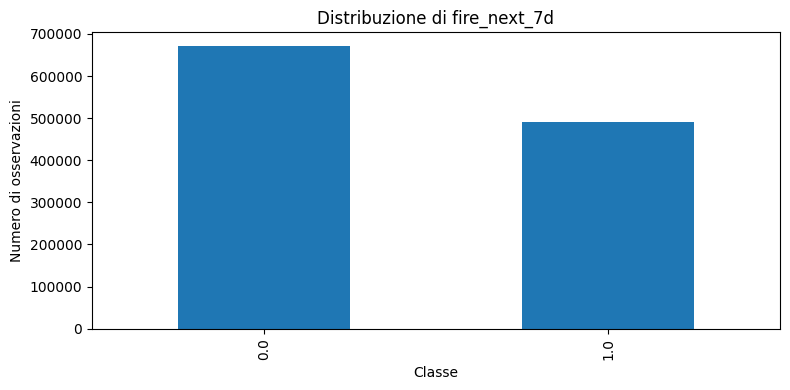

In [6]:
model_df = df.dropna(subset=target_columns).copy()

balance_rows = []
for target in ["fire_next_1d", "fire_next_3d", "fire_next_7d"]:
    counts = model_df[target].value_counts().reindex([0, 1], fill_value=0)
    n = counts.sum()
    balance_rows.append({
        "target": target,
        "n_0": int(counts[0]),
        "n_1": int(counts[1]),
        "pct_positivi": counts[1] / n * 100 if n else np.nan,
        "rapporto_negativi_positivi": counts[0] / counts[1] if counts[1] else np.inf,
    })

balance_report = pd.DataFrame(balance_rows)
display(balance_report)

print("Distribuzione del target di conteggio fire_count_next_7d:")
display(model_df["fire_count_next_7d"].describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame().T)

fig, ax = plt.subplots(figsize=(8, 4))
model_df["fire_next_7d"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribuzione di fire_next_7d")
ax.set_xlabel("Classe")
ax.set_ylabel("Numero di osservazioni")
plt.tight_layout()
plt.show()

## 7. Statistiche descrittive robuste

In [7]:
candidate_numeric = [
    "fire_count", "daily_frp_mean",
    "fire_count_last_1d", "fire_count_last_3d", "fire_count_last_7d",
    "frp_mean_last_3d", "frp_mean_last_7d",
    "frp_mean_last_3d_calc", "frp_mean_last_7d_calc",
    "frp_std_last_7d_calc", "frp_max_last_7d_calc",
    "frp_trend_3d_vs_7d", "frp_cv_last_7d",
    "days_since_last_fire", "fire_count_next_7d"
]
stat_columns = [c for c in candidate_numeric if c in model_df.columns]

rows = []
for col in stat_columns:
    s = pd.to_numeric(model_df[col], errors="coerce").dropna()
    q1, median, q3 = s.quantile([0.25, 0.50, 0.75])
    mean = s.mean()
    std = s.std(ddof=1)
    rows.append({
        "feature": col,
        "n": s.size,
        "missing_pct": model_df[col].isna().mean() * 100,
        "mean": mean,
        "median": median,
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "min": s.min(),
        "max": s.max(),
        "variance": s.var(ddof=1),
        "std": std,
        "cv": std / abs(mean) if mean != 0 else np.nan,
        "skewness": s.skew(),
        "kurtosis": s.kurt(),
    })

descriptive_stats = pd.DataFrame(rows).set_index("feature")
display(descriptive_stats)

,n,missing_pct,mean,median,q1,q3,iqr,min,max,variance,std,cv,skewness,kurtosis
feature,,,,,,,,,,,,,,
fire_count,1160355,0.0000,0.1979,0.0000,0.0000,0.0000,0.0000,0.0000,142.0000,1.6505,1.2847,6.4916,23.2308,"1,053.3557"
daily_frp_mean,1160355,0.0000,1.8715,0.0000,0.0000,0.0000,0.0000,0.0000,"2,106.3520",180.0638,13.4188,7.1699,35.5187,"2,826.3477"
fire_count_last_1d,1160355,0.0000,0.1979,0.0000,0.0000,0.0000,0.0000,0.0000,142.0000,1.6505,1.2847,6.4916,23.2308,"1,053.3557"
fire_count_last_3d,1160355,0.0000,0.5144,0.0000,0.0000,0.0000,0.0000,0.0000,142.0000,4.1658,2.0410,3.9676,15.0130,443.8668
fire_count_last_7d,1160355,0.0000,0.9560,0.0000,0.0000,1.0000,1.0000,0.0000,231.0000,11.9495,3.4568,3.6159,14.2692,394.4134
frp_mean_last_7d,320185,72.4063,25.1152,14.8500,9.0600,26.6400,17.5800,0.0000,"2,106.3520","1,750.7541",41.8420,1.6660,13.3171,361.1751
frp_mean_last_3d_calc,1105100,4.7619,2.0541,0.0000,0.0000,0.0000,0.0000,0.0000,702.1173,70.2239,8.3800,4.0797,19.7032,831.6917
frp_mean_last_7d_calc,1105100,4.7619,2.0919,0.0000,0.0000,1.8967,1.8967,0.0000,669.9692,44.2702,6.6536,3.1806,15.5632,564.7271
frp_std_last_7d_calc,1160355,0.0000,3.8589,0.0000,0.0000,3.9757,3.9757,0.0000,796.1262,145.4527,12.0604,3.1253,15.3122,506.9870


## 8. Outlier con metodo IQR

In [8]:
outlier_rows = []
for col in stat_columns:
    s = pd.to_numeric(model_df[col], errors="coerce")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)
    outlier_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_n": int(mask.sum()),
        "outlier_pct": mask.mean() * 100,
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_report)

print(
    "Nota: per variabili di incendio fortemente asimmetriche, gli outlier possono rappresentare "
    "eventi reali estremi. Non vengono eliminati automaticamente."
)

,feature,lower_bound,upper_bound,outlier_n,outlier_pct
10,frp_trend_3d_vs_7d,0.0000,0.0000,379806,32.7319
6,frp_mean_last_3d_calc,0.0000,0.0000,246377,21.2329
3,fire_count_last_3d,0.0000,0.0000,223768,19.2844
13,fire_count_next_7d,-1.5000,2.5000,179929,15.5064
7,frp_mean_last_7d_calc,-2.8450,4.7417,134490,11.5904
8,frp_std_last_7d_calc,-5.9636,9.9393,126835,10.9307
4,fire_count_last_7d,-1.5000,2.5000,118301,10.1952
9,frp_max_last_7d_calc,-16.2825,27.1375,112767,9.7183
0,fire_count,0.0000,0.0000,86473,7.4523
2,fire_count_last_1d,0.0000,0.0000,86473,7.4523


Nota: per variabili di incendio fortemente asimmetriche, gli outlier possono rappresentare eventi reali estremi. Non vengono eliminati automaticamente.


## 9. Bootstrap: stime più precise con intervalli di confidenza

In [9]:
def bootstrap_ci(values, statistic=np.mean, n_bootstrap=N_BOOTSTRAP,
                 confidence=0.95, random_state=RANDOM_STATE):
    values = pd.Series(values).dropna().to_numpy()
    if values.size == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    estimates = np.empty(n_bootstrap, dtype=float)
    for i in range(n_bootstrap):
        sample = rng.choice(values, size=values.size, replace=True)
        estimates[i] = statistic(sample)

    alpha = 1 - confidence
    lower, upper = np.quantile(estimates, [alpha / 2, 1 - alpha / 2])
    return statistic(values), lower, upper

bootstrap_rows = []
for target in ["fire_next_1d", "fire_next_3d", "fire_next_7d"]:
    estimate, lower, upper = bootstrap_ci(model_df[target], np.mean)
    bootstrap_rows.append({
        "metrica": f"percentuale positiva {target}",
        "stima": estimate * 100,
        "ic95_lower": lower * 100,
        "ic95_upper": upper * 100,
    })

estimate, lower, upper = bootstrap_ci(model_df["fire_count_next_7d"], np.mean)
bootstrap_rows.append({
    "metrica": "media fire_count_next_7d",
    "stima": estimate,
    "ic95_lower": lower,
    "ic95_upper": upper,
})

bootstrap_report = pd.DataFrame(bootstrap_rows)
display(bootstrap_report)

# Grafico Monte Carlo: stima puntuale e intervallo di confidenza bootstrap al 95%.
class_boot = bootstrap_report.iloc[:3].copy()
count_boot = bootstrap_report.iloc[3:].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, report, titolo, unita in [
    (axes[0], class_boot, "Probabilita di incendio", "Percentuale positiva"),
    (axes[1], count_boot, "Numero atteso di incendi", "Media conteggio"),
]:
    y = np.arange(len(report))
    ax.errorbar(
        report["stima"], y,
        xerr=[report["stima"] - report["ic95_lower"], report["ic95_upper"] - report["stima"]],
        fmt="o", capsize=5, color="tab:blue",
    )
    ax.set_yticks(y, report["metrica"])
    ax.set(title=titolo, xlabel=unita)
    ax.grid(axis="x", alpha=0.25)

fig.suptitle("Monte Carlo / bootstrap: stime e IC 95%", y=1.03)
plt.tight_layout()
plt.show()

,metrica,stima,ic95_lower,ic95_upper
0,percentuale positiva fire_next_1d,7.5906,7.5419,7.6389
1,percentuale positiva fire_next_3d,22.7718,22.6955,22.8474
2,percentuale positiva fire_next_7d,42.2372,42.1475,42.3282
3,media fire_count_next_7d,1.4395,1.4321,1.4468


## 10. Correlazioni adatte ai diversi target

In [10]:
feature_candidates = [
    "fire_count", "daily_frp_mean",
    "fire_count_last_1d", "fire_count_last_3d", "fire_count_last_7d",
    "frp_mean_last_3d", "frp_mean_last_7d",
    "frp_mean_last_3d_calc", "frp_mean_last_7d_calc",
    "frp_std_last_7d_calc", "frp_max_last_7d_calc",
    "frp_trend_3d_vs_7d", "frp_cv_last_7d",
    "days_since_last_fire", "sin_doy", "cos_doy",
    "sin_doy_calc", "cos_doy_calc", "history_length"
]
feature_cols = [
    c for c in feature_candidates
    if c in model_df.columns and pd.api.types.is_numeric_dtype(model_df[c])
]

correlation_rows = []
for feature in feature_cols:
    pair = model_df[[feature, "fire_next_7d", "fire_count_next_7d"]].dropna()
    if len(pair) < 3 or pair[feature].nunique() < 2:
        continue

    pearson_r, pearson_p = stats.pearsonr(pair[feature], pair["fire_next_7d"])
    spearman_r, spearman_p = stats.spearmanr(pair[feature], pair["fire_next_7d"])
    kendall_r, kendall_p = stats.kendalltau(pair[feature], pair["fire_next_7d"])
    point_r, point_p = stats.pointbiserialr(pair["fire_next_7d"], pair[feature])
    count_spearman_r, count_spearman_p = stats.spearmanr(
        pair[feature], pair["fire_count_next_7d"]
    )

    correlation_rows.append({
        "feature": feature,
        "point_biserial_r": point_r,
        "point_biserial_p": point_p,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "kendall_tau": kendall_r,
        "kendall_p": kendall_p,
        "count_spearman_r": count_spearman_r,
        "count_spearman_p": count_spearman_p,
    })

correlation_report = pd.DataFrame(correlation_rows)
if len(correlation_report):
    correlation_report["abs_point_biserial"] = correlation_report["point_biserial_r"].abs()
    correlation_report = correlation_report.sort_values("abs_point_biserial", ascending=False)
    display(correlation_report.drop(columns="abs_point_biserial"))

    # Matrice Spearman: mostra ridondanza e relazioni tra feature e target.
    matrix_cols = feature_cols + ["fire_next_7d", "fire_count_next_7d"]
    spearman_matrix = model_df[matrix_cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(14, 12))
    image = ax.imshow(spearman_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(matrix_cols)), matrix_cols, rotation=90, fontsize=8)
    ax.set_yticks(range(len(matrix_cols)), matrix_cols, fontsize=8)
    ax.set_title("Matrice di correlazione Spearman: feature e target")
    fig.colorbar(image, ax=ax, label="Correlazione Spearman")
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna correlazione calcolabile.")

,feature,point_biserial_r,point_biserial_p,pearson_r,pearson_p,spearman_r,spearman_p,kendall_tau,kendall_p,count_spearman_r,count_spearman_p
3,fire_count_last_3d,0.0918,0.0000,0.0918,0.0000,0.0933,0.0000,0.0902,0.0000,0.1369,0.0000
4,fire_count_last_7d,0.0751,0.0000,0.0751,0.0000,0.0438,0.0000,0.0416,0.0000,0.0848,0.0000
7,frp_mean_last_7d_calc,0.0700,0.0000,0.0700,0.0000,0.0693,0.0000,0.0630,0.0000,0.1238,0.0000
6,frp_mean_last_3d_calc,0.0680,0.0000,0.0680,0.0000,0.1010,0.0000,0.0955,0.0000,0.1493,0.0000
2,fire_count_last_1d,0.0599,0.0000,0.0599,0.0000,0.0438,0.0000,0.0433,0.0000,0.0648,0.0000
0,fire_count,0.0599,0.0000,0.0599,0.0000,0.0438,0.0000,0.0433,0.0000,0.0648,0.0000
12,days_since_last_fire,0.0585,0.0000,0.0585,0.0000,-0.0039,0.0000,-0.0035,0.0000,-0.0573,0.0000
8,frp_std_last_7d_calc,0.0534,0.0000,0.0534,0.0000,0.0603,0.0000,0.0552,0.0000,0.1104,0.0000
9,frp_max_last_7d_calc,0.0498,0.0000,0.0498,0.0000,0.0618,0.0000,0.0562,0.0000,0.1153,0.0000
17,history_length,0.0423,0.0000,0.0423,0.0000,0.0423,0.0000,0.0353,0.0000,0.0404,0.0000


## 11. Mutual Information per relazioni non lineari

In [11]:
mi_data = model_df[feature_cols + ["fire_next_7d", "fire_count_next_7d"]].copy()

# Imputazione mediana usata soltanto per il calcolo diagnostico della Mutual Information.
X_mi = mi_data[feature_cols].replace([np.inf, -np.inf], np.nan)
X_mi = X_mi.fillna(X_mi.median(numeric_only=True)).fillna(0)

y_class = mi_data["fire_next_7d"].astype(int)
y_count = mi_data["fire_count_next_7d"].clip(lower=0)

mi_class = mutual_info_classif(X_mi, y_class, random_state=RANDOM_STATE)
mi_count = mutual_info_regression(X_mi, y_count, random_state=RANDOM_STATE)

mi_report = pd.DataFrame({
    "feature": feature_cols,
    "mutual_info_fire_next_7d": mi_class,
    "mutual_info_fire_count_next_7d": mi_count,
}).sort_values("mutual_info_fire_next_7d", ascending=False)

display(mi_report)

,feature,mutual_info_fire_next_7d,mutual_info_fire_count_next_7d
12,days_since_last_fire,0.1113,0.0362
5,frp_mean_last_7d,0.0904,0.0817
9,frp_max_last_7d_calc,0.0536,0.1219
8,frp_std_last_7d_calc,0.0502,0.1029
11,frp_cv_last_7d,0.0443,0.0532
7,frp_mean_last_7d_calc,0.0389,0.0912
10,frp_trend_3d_vs_7d,0.0336,0.0651
6,frp_mean_last_3d_calc,0.0210,0.0472
15,sin_doy_calc,0.0142,0.0085
17,history_length,0.0137,0.0076


## 12. Confronto tra classi e significatività statistica

In [12]:
class_comparison_rows = []

for feature in feature_cols:
    group_0 = model_df.loc[model_df["fire_next_7d"] == 0, feature].dropna()
    group_1 = model_df.loc[model_df["fire_next_7d"] == 1, feature].dropna()

    if len(group_0) < 2 or len(group_1) < 2:
        continue

    # Mann-Whitney è più robusto di un t-test per distribuzioni asimmetriche.
    u_stat, p_value = stats.mannwhitneyu(group_0, group_1, alternative="two-sided")

    # Rank-biserial effect size: segno e intensità della separazione.
    rank_biserial = 2 * u_stat / (len(group_0) * len(group_1)) - 1

    class_comparison_rows.append({
        "feature": feature,
        "n_class_0": len(group_0),
        "n_class_1": len(group_1),
        "median_class_0": group_0.median(),
        "median_class_1": group_1.median(),
        "mean_class_0": group_0.mean(),
        "mean_class_1": group_1.mean(),
        "mann_whitney_u": u_stat,
        "p_value": p_value,
        "rank_biserial_effect": rank_biserial,
    })

class_comparison = pd.DataFrame(class_comparison_rows)
if len(class_comparison):
    class_comparison["significant_0_05"] = class_comparison["p_value"] < 0.05
    class_comparison["abs_effect"] = class_comparison["rank_biserial_effect"].abs()
    class_comparison = class_comparison.sort_values(
        ["significant_0_05", "abs_effect"], ascending=[False, False]
    )
    display(class_comparison.drop(columns="abs_effect"))
else:
    print("Confronto tra classi non calcolabile.")

,feature,n_class_0,n_class_1,median_class_0,median_class_1,mean_class_0,mean_class_1,mann_whitney_u,p_value,rank_biserial_effect,significant_0_05
5,frp_mean_last_7d,179830,140355,13.4075,16.7737,23.6103,27.0433,"10,809,236,115.0000",0.0000,-0.1435,True
6,frp_mean_last_3d_calc,635222,469878,0.0000,0.0000,1.5636,2.7171,"136,412,790,384.5000",0.0000,-0.0859,True
3,fire_count_last_3d,670254,490101,0.0000,0.0000,0.3542,0.7335,"151,923,430,145.5000",0.0000,-0.0750,True
7,frp_mean_last_7d_calc,635222,469878,0.0000,0.0000,1.6913,2.6335,"138,744,132,210.5000",0.0000,-0.0703,True
9,frp_max_last_7d_calc,635222,469878,0.0000,0.0000,8.8902,12.0458,"139,878,565,281.5000",0.0000,-0.0627,True
8,frp_std_last_7d_calc,670254,490101,0.0000,0.0000,3.3079,4.6125,"154,413,413,033.0000",0.0000,-0.0599,True
13,sin_doy,670254,490101,0.0602,0.0602,0.0636,0.0548,"172,355,301,627.0000",0.0000,0.0494,True
15,sin_doy_calc,670254,490101,0.0623,0.0623,0.0657,0.0569,"172,355,301,627.0000",0.0000,0.0494,True
17,history_length,670254,490101,10.0000,10.0000,9.7810,10.2994,"156,136,854,027.0000",0.0000,-0.0494,True
4,fire_count_last_7d,670254,490101,0.0000,0.0000,0.7339,1.2597,"157,631,328,561.0000",0.0000,-0.0403,True


## 13. Potere discriminante univariato tramite ROC-AUC

In [13]:
auc_rows = []
for feature in feature_cols:
    pair = model_df[[feature, "fire_next_7d"]].replace([np.inf, -np.inf], np.nan).dropna()
    if pair[feature].nunique() < 2 or pair["fire_next_7d"].nunique() < 2:
        continue

    auc = roc_auc_score(pair["fire_next_7d"], pair[feature])
    # Una relazione inversa può comunque essere predittiva.
    adjusted_auc = max(auc, 1 - auc)
    direction = "diretta" if auc >= 0.5 else "inversa"

    auc_rows.append({
        "feature": feature,
        "roc_auc_raw": auc,
        "roc_auc_adjusted": adjusted_auc,
        "direction": direction,
    })

auc_report = pd.DataFrame(auc_rows).sort_values("roc_auc_adjusted", ascending=False)
display(auc_report)

,feature,roc_auc_raw,roc_auc_adjusted,direction
5,frp_mean_last_7d,0.5717,0.5717,diretta
6,frp_mean_last_3d_calc,0.5430,0.5430,diretta
3,fire_count_last_3d,0.5375,0.5375,diretta
7,frp_mean_last_7d_calc,0.5352,0.5352,diretta
9,frp_max_last_7d_calc,0.5314,0.5314,diretta
8,frp_std_last_7d_calc,0.5299,0.5299,diretta
17,history_length,0.5247,0.5247,diretta
13,sin_doy,0.4753,0.5247,inversa
15,sin_doy_calc,0.4753,0.5247,inversa
4,fire_count_last_7d,0.5201,0.5201,diretta


## 14. Ridondanza e multicollinearità tra feature

,feature_1,feature_2,abs_spearman
151,sin_doy_calc,history_length,1.0000
146,sin_doy,history_length,1.0000
144,sin_doy,sin_doy_calc,1.0000
0,fire_count,daily_frp_mean,0.9989
148,cos_doy,cos_doy_calc,0.9977
99,frp_mean_last_7d_calc,frp_max_last_7d_calc,0.9925
78,frp_mean_last_7d,frp_max_last_7d_calc,0.9860
77,frp_mean_last_7d,frp_std_last_7d_calc,0.9813
108,frp_std_last_7d_calc,frp_max_last_7d_calc,0.9791
98,frp_mean_last_7d_calc,frp_std_last_7d_calc,0.9640


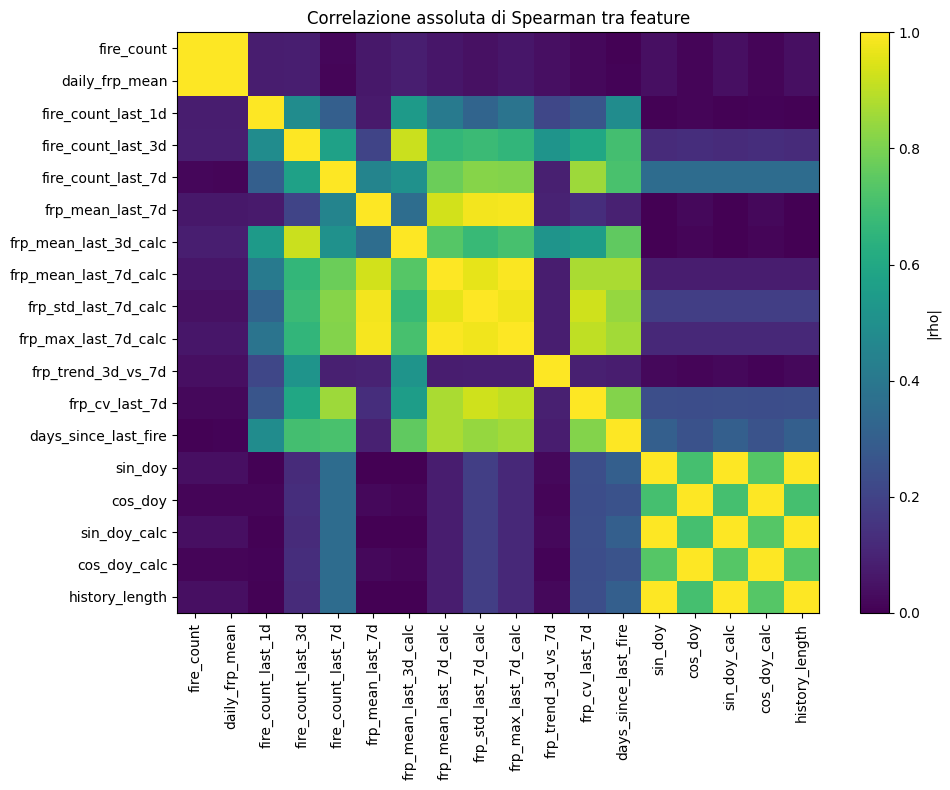

In [14]:
corr_matrix = model_df[feature_cols].corr(method="spearman").abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_pairs = (
    upper_triangle.stack()
    .rename("abs_spearman")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .query("abs_spearman >= 0.90")
    .sort_values("abs_spearman", ascending=False)
)

display(redundant_pairs)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlazione assoluta di Spearman tra feature")
fig.colorbar(image, ax=ax, label="|rho|")
plt.tight_layout()
plt.show()

## 15. Controllo temporale dei target e possibili incoerenze

In [15]:
target_consistency = pd.DataFrame({
    "regola": [
        "fire_next_1d <= fire_next_3d",
        "fire_next_3d <= fire_next_7d",
        "fire_next_7d coerente con fire_count_next_7d > 0",
        "fire_count_next_7d non negativo",
    ],
    "violazioni": [
        int((model_df["fire_next_1d"] > model_df["fire_next_3d"]).sum()),
        int((model_df["fire_next_3d"] > model_df["fire_next_7d"]).sum()),
        int((model_df["fire_next_7d"] != (model_df["fire_count_next_7d"] > 0).astype(int)).sum()),
        int((model_df["fire_count_next_7d"] < 0).sum()),
    ]
})
target_consistency["violazioni_pct"] = target_consistency["violazioni"] / len(model_df) * 100

display(target_consistency)

,regola,violazioni,violazioni_pct
0,fire_next_1d <= fire_next_3d,0,0.0000
1,fire_next_3d <= fire_next_7d,0,0.0000
2,fire_next_7d coerente con fire_count_next_7d > 0,0,0.0000
3,fire_count_next_7d non negativo,0,0.0000


## 16. Salvataggio del dataset migliorato e dei report

In [16]:
# Mantiene soltanto le righe utilizzabili per i target supervisionati.
model_df.to_csv(OUTPUT_FILE, index=False)

REPORT_DIR = Path("report_statistici_incendi")
REPORT_DIR.mkdir(exist_ok=True)

quality_report.to_csv(REPORT_DIR / "quality_report.csv")
balance_report.to_csv(REPORT_DIR / "target_balance.csv", index=False)
descriptive_stats.to_csv(REPORT_DIR / "descriptive_statistics.csv")
outlier_report.to_csv(REPORT_DIR / "outlier_report.csv", index=False)
bootstrap_report.to_csv(REPORT_DIR / "bootstrap_confidence_intervals.csv", index=False)
mi_report.to_csv(REPORT_DIR / "mutual_information.csv", index=False)
auc_report.to_csv(REPORT_DIR / "univariate_auc.csv", index=False)
target_consistency.to_csv(REPORT_DIR / "target_consistency.csv", index=False)

if "correlation_report" in globals() and len(correlation_report):
    correlation_report.to_csv(REPORT_DIR / "correlations.csv", index=False)
if "class_comparison" in globals() and len(class_comparison):
    class_comparison.to_csv(REPORT_DIR / "class_comparison.csv", index=False)
if len(redundant_pairs):
    redundant_pairs.to_csv(REPORT_DIR / "redundant_feature_pairs.csv", index=False)
if len(comparison_report):
    comparison_report.to_csv(REPORT_DIR / "rolling_feature_validation.csv", index=False)

print(f"Dataset migliorato salvato in: {OUTPUT_FILE.resolve()}")
print(f"Report salvati nella cartella: {REPORT_DIR.resolve()}")
print(f"Dimensioni finali: {model_df.shape}")

Dataset migliorato salvato in: /Users/mac/Documents/SpaceRiskIntelligence-main 2/cambiamenti_climatici/claudia/dataset_pulito5_migliorato.csv
Report salvati nella cartella: /Users/mac/Documents/SpaceRiskIntelligence-main 2/cambiamenti_climatici/claudia/report_statistici_incendi
Dimensioni finali: (1160355, 48)


## 17. Indicazioni per il modello predittivo

Per ottenere valutazioni realistiche:

1. **non utilizzare uno split casuale**;
2. dividere train, validation e test in ordine temporale;
3. calcolare eventuali trasformazioni soltanto sul training set;
4. valutare `fire_next_1d`, `fire_next_3d` e `fire_next_7d` con PR-AUC, recall, precision, F1 e ROC-AUC;
5. valutare `fire_count_next_7d` con MAE, RMSE e devianza Poisson;
6. confrontare il modello con baseline semplici, ad esempio “nessun incendio futuro” e persistenza dell'attività recente;
7. considerare pesi di classe o modelli adatti a eventi rari, evitando oversampling prima della divisione temporale.

Le correlazioni e i test statistici di questo notebook sono strumenti esplorativi: non dimostrano causalità e non sostituiscono una validazione temporale del modello.